## Try product space with ensemble 

In [1]:
import os
from time import time
import pickle
import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import numpy as jnp
from functools import partial
from fastgb import fastgb
from globalfit.gb.generator import GBGenerator, fastgb_buffersize, FastGBExt
from globalfit.gb.block import GBBlock
from globalfit.gb.likelihood import GBLogLik
from globalfit.gb.likelihood_jax import GBLogLikJax
from globalfit.noise.generator import NoiseGenerator
from globalfit.gb.tools import XYZ2AET
from lisaorbits import EqualArmlengthOrbits

# from eryn.ensemble import EnsembleSampler
# from eryn.state import State
# from eryn.prior import ProbDistContainer, uniform_dist
# from eryn.utils import TransformContainer
# from eryn.moves import GaussianMove, StretchMove, CombineMove, MHMove
# from eryn.utils.utility import groups_from_inds

import corner

from ptdamh import runner as my_mcmc
from ptdamh import proposals as Proposals
from ptdamh import ensemble_runner as ensemble_mcmc

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)

%load_ext autoreload
%autoreload 2

In [2]:
jax.config.update("jax_enable_x64", True)
GF_REPO = os.path.realpath("/Users/stas/Projects/LISA/GlobalFit/global-fit/")

Tobs = 10485760.0
dt = 5.0
bsize = 64

In [3]:
np.random.seed(15)  # fixing the noise 

_noise_file = os.path.join(GF_REPO, 'auxfiles', 'noise_pars.h5')
_gbfile = os.path.join(GF_REPO, 'auxfiles', 'gb_true.h5')

_gbcat = GBGenerator.load_catalog(_gbfile)

gb_fband = [6.216e-3, 6.219e-3]
duration = [0, 10485760.0]
_sel = (_gbcat['Frequency'] > gb_fband[0]) & (_gbcat['Frequency'] < gb_fband[1])
_list = np.where(_sel)[0]

cfg = {
    "dt":dt,
    "gb_fband": gb_fband, 
    "AET": True,
    "ignore_T_channel": True,
    "domain": 'Frequency',
    "duration": duration, 
    "inputs": [
        {"add": [{"name":"cat", "generator": GBGenerator, "list": _list}], "file": _gbfile}, 
        {"add": [{"name":"cat", "generator": NoiseGenerator}], "file": _noise_file},
    ],
    "noise_params": _noise_file
} 
block = GBBlock(config=cfg)
block.load_tdi()
block.load_noise()

print (_gbcat[_list])

[(2.14104362e-23, 0.00621747, 3.08540766e-16,  0.19122362, 4.78383106, 1.44883313, 3.24941449, 3.90238858, 0., 0., 0., 0., 0., 0., 0., 0.,  7.47269928, 0., '', 0, 0.)
 (3.50476905e-23, 0.00621856, 1.31240183e-15, -0.16938328, 4.60813132, 1.79614242, 3.5511628 , 5.81270134, 0., 0., 0., 0., 0., 0., 0., 0., 13.37559459, 0., '', 0, 0.)
 (2.45939760e-23, 0.0062182 , 5.56699233e-16, -1.08865091, 3.03280483, 1.62098072, 1.30826979, 3.55278411, 0., 0., 0., 0., 0., 0., 0., 0.,  8.28745113, 0., '', 0, 0.)]


In [4]:
def _gbll_inst(cls, nsrcs, bsize, unroll_srcs=None, unroll_tdi=None):
    return cls(
        block.tdi,
        block.noise,
        block.fmin,
        block.fmax,
        smax=nsrcs,
        fgb_ext=bsize,
        unroll_srcs=unroll_srcs,
        unroll_tdi=unroll_tdi
    )

Nsrc=3
Npar_src = 8
dim = Nsrc * Npar_src
bsize = 64

fold_idx = (4, 6, 7, 4+Npar_src, 6+Npar_src, 7+Npar_src, 4+2*Npar_src, 6+2*Npar_src, 7+2*Npar_src)

_gbll = _gbll_inst(GBLogLik, Nsrc, bsize).loglik
jllkwargs = {}
_jgbll = jax.vmap(jax.jit(_gbll_inst(GBLogLikJax, Nsrc, bsize, **jllkwargs).loglik))

GB2_loglik = jax.jit(_gbll_inst(GBLogLikJax, 2, bsize, **jllkwargs).loglik)
GB3_loglik = jax.jit(_gbll_inst(GBLogLikJax, 3, bsize, **jllkwargs).loglik)


_srcHC245 = _gbll_inst(GBLogLik, 3, bsize).ldc_to_pars(_gbcat[_list], dicts=True)
print (_srcHC245)
_srcHC24 = _srcHC245[:2*Npar_src] 

print ("make sure we fixed the noise", GB3_loglik(_srcHC245))
# make sure we fixed the noise -203.4598 for seed= 15

[0.33265638 0.4898206  0.5084293  0.59503018 0.76137036 0.56083053
 0.65540519 0.08676368 0.38616485 0.85278449 0.53585466 0.41571276
 0.73340688 0.38827814 0.05549038 0.29474992 0.34770719 0.7330147
 0.51520896 0.05699891 0.48268588 0.47491833 0.98187836 0.64900794]
make sure we fixed the noise -203.45983125330835


In [5]:
from jax import lax

# print(initial_thetas.shape)
# print (jax.vmap(GB3_loglik)(initial_thetas))


def make_nonperiodic_mask(D: int, fold_idx=()):
    """mask[d]=True iff dim d is box-constrained (non-periodic)."""
    m = jnp.ones((D,), dtype=bool)
    if len(fold_idx):
        m = m.at[jnp.asarray(fold_idx, dtype=int)].set(False)
    return m

def make_boxed_logprob(log_prob_fn_single, *, low=0.0, high=1.0,
                       check_mask: jnp.ndarray | None = None):
    """
    Wrap (D,) -> () function with a [low,high] box prior on dims where check_mask==True.
    Returns a new (D,) -> () that yields -inf outside the box, and
    uses lax.cond so the heavy log_prob is NOT evaluated when invalid.
    """
    low = jnp.asarray(low); high = jnp.asarray(high)

    def _one(theta: jnp.ndarray):
        theta = jnp.asarray(theta)
        if check_mask is None:
            inside_all = jnp.all((theta >= low) & (theta <= high))
        else:
            # Only enforce on masked dims; others ignored (e.g., periodic)
            in_dim = (theta >= low) & (theta <= high)
            inside_all = jnp.all(jnp.where(check_mask, in_dim, True))

        def _do():   return log_prob_fn_single(theta)
        def _bad():  return jnp.array(-jnp.inf, dtype=theta.dtype)

        return lax.cond(inside_all, _do, _bad)

    return _one

fold_idx3 = (4, 6, 7, 4+Npar_src, 6+Npar_src, 7+Npar_src, 4+2*Npar_src, 6+2*Npar_src, 7+2*Npar_src)
fold_idx2 = (4, 6, 7, 4+Npar_src, 6+Npar_src, 7+Npar_src)

check_mask3 = make_nonperiodic_mask(dim, fold_idx3)           # True == enforce [0,1]
check_mask2 = make_nonperiodic_mask(2*Npar_src, fold_idx2)           # True == enforce [0,1]
boxed_log_probG3 = make_boxed_logprob(GB3_loglik,           # your original fn
                                    low=0.0, high=1.0,
                                    check_mask=check_mask3)

boxed_log_probG2 = make_boxed_logprob(GB2_loglik,           # your original fn
                                    low=0.0, high=1.0,
                                    check_mask=check_mask2)

# print (jax.vmap(boxed_log_probG3)(initial_thetas))
print (boxed_log_probG2(_srcHC24))

-243.38607198772013


In [6]:
key = jax.random.PRNGKey(42)

Num_temps = 10
Tmax = 10
Nsrc = 3
Npar_src = 8
dim = Nsrc * Npar_src
walkers = 32


cov = jnp.diag(jnp.full(dim, 0.01**2))
temps = my_mcmc.temperature_ladder(n_temps=Num_temps, T_min=1.0, T_max=Tmax, kind="geom", cold_dense=True, power=1.5)
print ('temperatures', temps)

key, subkey = jax.random.split(key)
noise = 1e-3 * jax.random.normal(subkey, shape=(Num_temps, walkers, dim))
initial_thetas = jnp.broadcast_to(_srcHC245, (Num_temps, walkers, dim)) + noise
initial_thetas = jnp.clip(initial_thetas, 0.0, 1.0) # ensure they are in [0,1]
print("Initial thetas shape:", initial_thetas.shape)

baseweight = (0.0, 0.8, 0.0, 0.1, 0.1)
weights = np.array([baseweight] * len(temps))


cfg = my_mcmc.AdaptConfig(
    m_epochs=300,       # number of adaptation epochs
    N_steps=500,      # number of steps per epoch
    # cov_mode = "all_states"
)


# cov = np.load('chains/cov_s245.npy')




temperatures [ 1.         1.089023   1.2727895  1.557579   1.978319   2.5946975
  3.5021207  4.852165   6.8873568 10.000001 ]
Initial thetas shape: (10, 32, 24)


In [ ]:
final_state, out_info = ensemble_mcmc.run_adaptive_pt_device_fast(
    key=key,
    initial_thetas=initial_thetas,
    temperatures=temps,
    log_prob_fn_single=boxed_log_probG2,
    base_cov= cov,
    fold_idx=fold_idx,
    weights=weights,
    cfg=cfg,
    lik_chunk=64,
    product_space=True,
    Npar_src=Npar_src,
    loglik_M2_single=boxed_log_probG2,
    loglik_M3_single=boxed_log_probG3,
    model_update_stride=5,
    log_prior_z=(0.0, 0.0),          # prior on z
    initial_z=np.zeros(len(temps), dtype=np.int32),  # optional
)



Adaptive PT (ensemble):   3%|▎         | 10/300 [02:50<1:23:12, 17.22s/epoch]

Epoch 10/300 | swap_rate=0.550 | mean_acc=0.326 | p(z=1)=0.341


Adaptive PT (ensemble):   7%|▋         | 20/300 [05:52<1:27:07, 18.67s/epoch]

Epoch 20/300 | swap_rate=0.521 | mean_acc=0.273 | p(z=1)=0.403


Adaptive PT (ensemble):  10%|█         | 30/300 [09:06<1:25:51, 19.08s/epoch]

...

Adaptive PT (ensemble):  77%|███████▋  | 230/300 [1:36:34<38:18, 32.84s/epoch]

Epoch 230/300 | swap_rate=0.509 | mean_acc=0.164 | p(z=1)=0.581


Adaptive PT (ensemble):  80%|████████  | 240/300 [1:42:08<33:19, 33.33s/epoch]

Epoch 240/300 | swap_rate=0.504 | mean_acc=0.164 | p(z=1)=0.597


Adaptive PT (ensemble):  83%|████████▎ | 249/300 [1:47:20<30:29, 35.88s/epoch]

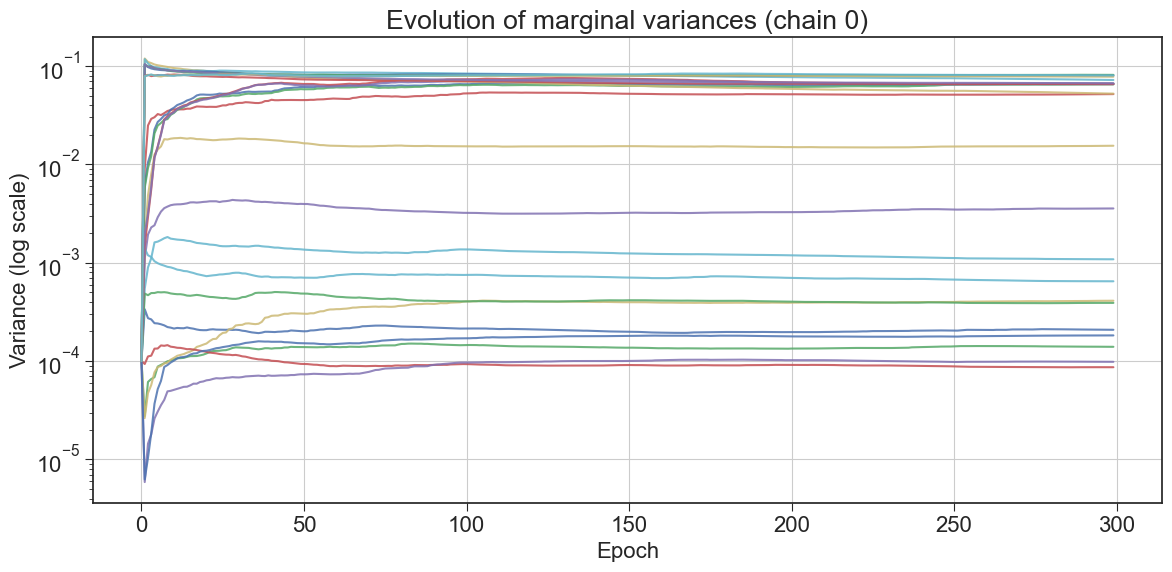

In [8]:


# ---------- epoch joiners (ragged per walker) ----------

def _concat_per_epoch_ragged(arrs_per_epoch):
    """
    arrs_per_epoch: list over epochs of np.ndarray (N_e, ...) or empty (N=0)
    Returns concatenated array along axis=0; empty (0,...) if none.
    """
    arrs = [a for a in arrs_per_epoch if a is not None and a.size > 0]
    if not arrs:
        # try to infer trailing shape from first non-None even if empty
        return np.empty((0,))
    return np.concatenate(arrs, axis=0)

def get_logprobs_per_cw(out, c, *, burnin_epochs=0, models=("M2","M3")):
    """
    Returns: list length W, each a 1D np.ndarray of concatenated log-probs
    over epochs (skipping first burnin_epochs), for temperature index c.
    models: tuple subset of {"M2","M3"} to include in the pool.
    """
    slims = out["slim_per_epoch"][burnin_epochs:]  # list of SlimInfoPS
    if not slims:
        return []
    W = len(slims[0].accepted_logprob_M2[c])
    res = []
    for w in range(W):
        pieces = []
        if "M2" in models:
            pieces += [slim.accepted_logprob_M2[c][w] for slim in slims]
        if "M3" in models:
            pieces += [slim.accepted_logprob_M3[c][w] for slim in slims]
        res.append(_concat_per_epoch_ragged(pieces))
    return res  # list of W arrays (ragged)

def get_points_per_cw(out, c, *, burnin_epochs=0, model="M2"):
    """
    Returns: list length W, each a 2D np.ndarray (N, D) of concatenated samples
    (accepted points) for given temperature c and model "M2" or "M3".
    """
    assert model in ("M2", "M3")
    slims = out["slim_per_epoch"][burnin_epochs:]
    if not slims:
        return []
    W = len(slims[0].accepted_points_M2[c])
    attr = "accepted_points_M2" if model == "M2" else "accepted_points_M3"
    res = []
    for w in range(W):
        pieces = [getattr(slim, attr)[c][w] for slim in slims]
        pts = _concat_per_epoch_ragged(pieces)
        if pts.ndim == 1:  # empty fallback from _concat_per_epoch_ragged
            pts = np.empty((0, 0))
        res.append(pts)
    return res  # list of W arrays (N, D)

def pool_walkers(arrs):
    """Concatenate a list of arrays arrs = [arr_w], gracefully handling empties."""
    arrs = [a for a in arrs if a is not None and a.size > 0]
    if not arrs:
        return np.empty((0,) + (() if arrs == [] else ()))
    return np.concatenate(arrs, axis=0)

# ---------- acceptance / swap pulled from per-epoch ----------
def get_accept_rate_per_cw_over_epochs(out, *, burnin_epochs=0):
    """Returns (E', C, W) array of per-(chain,walker) acceptance by epoch."""
    slims = out["slim_per_epoch"][burnin_epochs:]
    A = [np.asarray(s.accept_rate_per_cw) for s in slims]  # each (C, W)
    return np.stack(A, axis=0) if A else np.empty((0,))

def get_accept_rate_per_c_over_epochs(out, *, burnin_epochs=0):
    """Returns (E', C) array of per-chain (walkers combined) acceptance by epoch."""
    slims = out["slim_per_epoch"][burnin_epochs:]
    A = [np.asarray(s.accept_rate_per_c) for s in slims]   # each (C,)
    return np.stack(A, axis=0) if A else np.empty((0,))

def get_swap_rate_per_w_edge_over_epochs(out, *, burnin_epochs=0):
    """Returns (E', W, C-1) swap rates per-epoch (averaged within epoch steps)."""
    slims = out["slim_per_epoch"][burnin_epochs:]
    S = [np.asarray(s.swap_rate_per_w_edge) for s in slims]  # each (W, C-1)
    return np.stack(S, axis=0) if S else np.empty((0,))

def get_swap_rate_per_edge_over_epochs(out, *, burnin_epochs=0):
    """Returns (E', C-1) epoch-wise per-edge swap rates (averaged over walkers)."""
    slims = out["slim_per_epoch"][burnin_epochs:]
    S = [np.asarray(s.swap_rate_per_edge) for s in slims]  # each (C-1,)
    return np.stack(S, axis=0) if S else np.empty((0,))


covs_over_time = out_info['covs_per_epoch']
E, C, D, _ = covs_over_time.shape
chain_id = 0  # cold chain
vars_evol = np.array([np.diag(covs_over_time[e, chain_id]) for e in range(E)])  # (E, D)

plt.figure(figsize=(12, 6))
for d in range(D):
    plt.semilogy(vars_evol[:, d], label=f"param {d}", alpha=0.85)
plt.xlabel("Epoch")
plt.ylabel("Variance (log scale)")
plt.title(f"Evolution of marginal variances (chain {chain_id})")
# plt.legend(ncol=4, fontsize=9)  # uncomment if you want legend
plt.tight_layout()
plt.show()

In [9]:
def plot_logprob_per_walker(out, c, *, burnin_epochs=0, max_walkers=None):
    series = get_logprobs_per_cw(out, c, burnin_epochs=burnin_epochs, models=("M2","M3"))
    if not series:
        print("No epochs (after burn-in).")
        return
    W = len(series) if max_walkers is None else min(max_walkers, len(series))
    plt.figure(figsize=(12, 6))
    for w in range(W):
        arr = series[w]
        if arr.size == 0: continue
        plt.plot(np.arange(arr.size), arr, lw=1.0, alpha=0.8, label=f"walker {w}")
    plt.xlabel("accepted index (concatenated over epochs)")
    plt.ylabel("log p(θ)")
    plt.title(f"Accepted log-probabilities per walker @ temp c={c}")
    plt.legend(ncol=2, fontsize=9, frameon=False)
    plt.tight_layout(); plt.show()

def plot_logprob_pooled(out, c, *, burnin_epochs=0, bins=50):
    series = get_logprobs_per_cw(out, c, burnin_epochs=burnin_epochs, models=("M2","M3"))
    pooled = pool_walkers(series)
    if pooled.size == 0:
        print("No accepted log-probs after burn-in.")
        return
    plt.figure(figsize=(10, 4.5))
    plt.subplot(1,2,1)
    plt.plot(np.arange(pooled.size), pooled, lw=1.0)
    plt.xlabel("accepted index"); plt.ylabel("log p(θ)")
    plt.title(f"Pooled trace @ temp c={c}")
    plt.subplot(1,2,2)
    plt.hist(pooled, bins=bins, density=True, alpha=0.8, histtype='stepfilled')
    plt.xlabel("log p(θ)"); plt.ylabel("density")
    plt.title("Pooled histogram")
    plt.tight_layout(); plt.show()


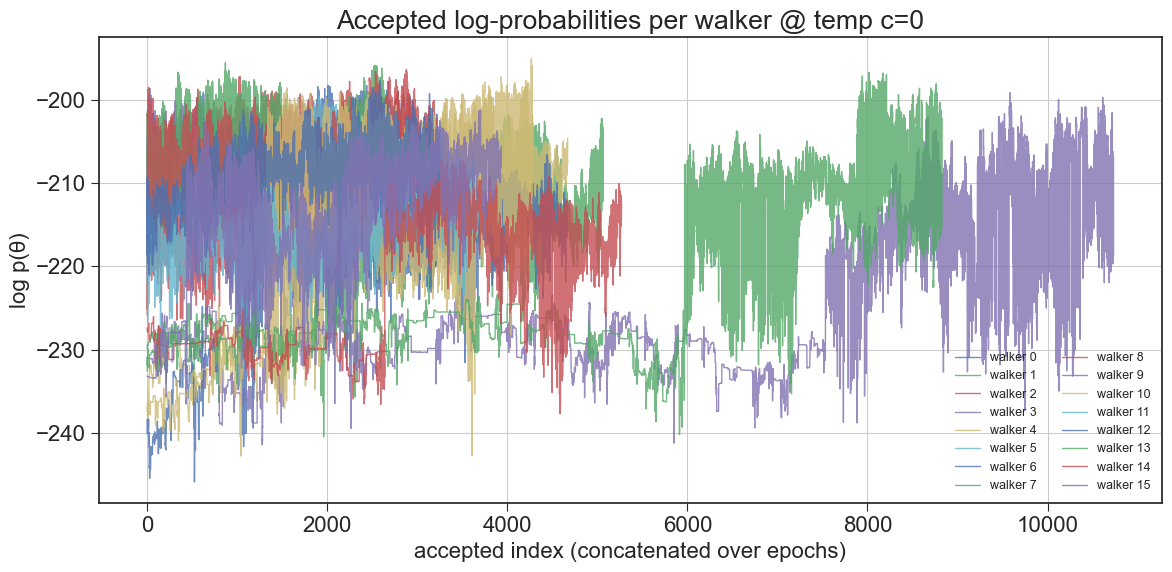

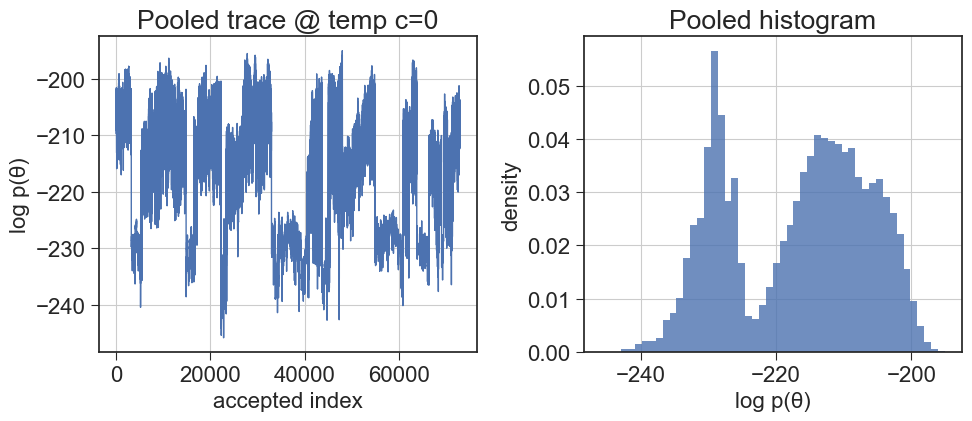

In [10]:
 plot_logprob_per_walker(out_info, c=0, burnin_epochs=75)
 plot_logprob_pooled(out_info, c=0, burnin_epochs=75)



In [11]:
def plot_acceptance_diagnostics(out, *, burnin_epochs=0):
    A_cw = get_accept_rate_per_cw_over_epochs(out, burnin_epochs=burnin_epochs)  # (E', C, W)
    A_c  = get_accept_rate_per_c_over_epochs(out,  burnin_epochs=burnin_epochs)  # (E', C)
    S_we = get_swap_rate_per_w_edge_over_epochs(out, burnin_epochs=burnin_epochs)  # (E', W, C-1)
    S_e  = get_swap_rate_per_edge_over_epochs(out, burnin_epochs=burnin_epochs)    # (E', C-1)

    if A_c.size:
        E, C = A_c.shape
        plt.figure(figsize=(12, 4))
        plt.plot(np.arange(E), A_c.mean(axis=1), marker='o')
        plt.axhline(0.2, ls='--', color='gray'); plt.axhline(0.4, ls='--', color='gray')
        plt.xlabel("epoch (post burn-in)"); plt.ylabel("mean acceptance across chains")
        plt.title("Acceptance vs epoch (combined over walkers)")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(14, 6))
        for c in range(C):
            plt.plot(np.arange(E), A_c[:, c], lw=1.0, alpha=0.8, label=f"c={c}")
        plt.xlabel("epoch"); plt.ylabel("acceptance (walkers combined)")
        plt.title("Per-chain acceptance vs epoch")
        plt.legend(ncol=4, fontsize=8, frameon=False)
        plt.tight_layout(); plt.show()

    if S_e.size:
        E, Cminus1 = S_e.shape
        plt.figure(figsize=(12, 4))
        plt.plot(np.arange(E), S_e.mean(axis=1), marker='o')
        plt.xlabel("epoch"); plt.ylabel("mean swap acc (across edges)")
        plt.title("Swap acceptance vs epoch (overall)")
        plt.ylim(0,1); plt.tight_layout(); plt.show()

        # heatmap: avg over epochs for each walker×edge
        if S_we.size:
            H = S_we.mean(axis=0)  # (W, C-1)
            plt.figure(figsize=(max(12, 0.6*(Cminus1+10)), max(6, 0.6*(H.shape[0]+8))))
            im = plt.imshow(H, aspect='auto', interpolation='nearest', cmap='viridis', vmin=0, vmax=1)
            plt.colorbar(im, label='swap acceptance', shrink=0.85)
            plt.xlabel('edge (i↔i+1)'); plt.ylabel('walker')
            plt.title('Swap acceptance (avg over epochs) per walker × edge')
            plt.tight_layout(); plt.show()


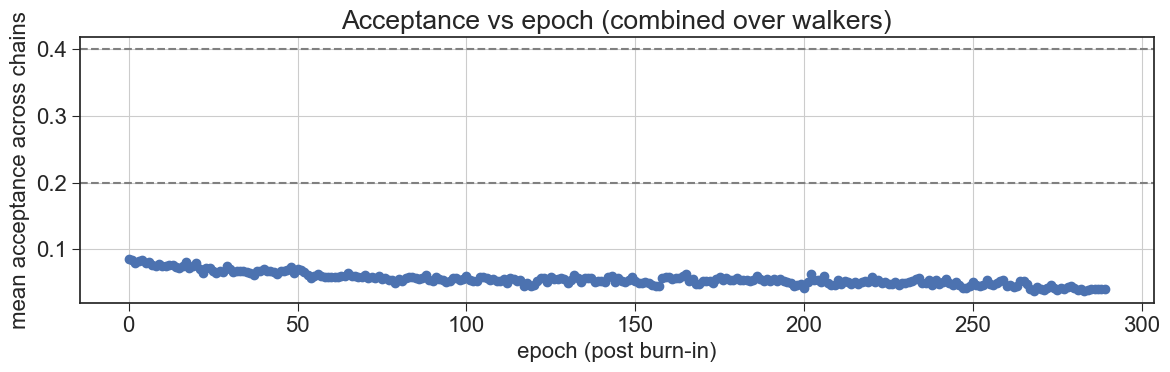

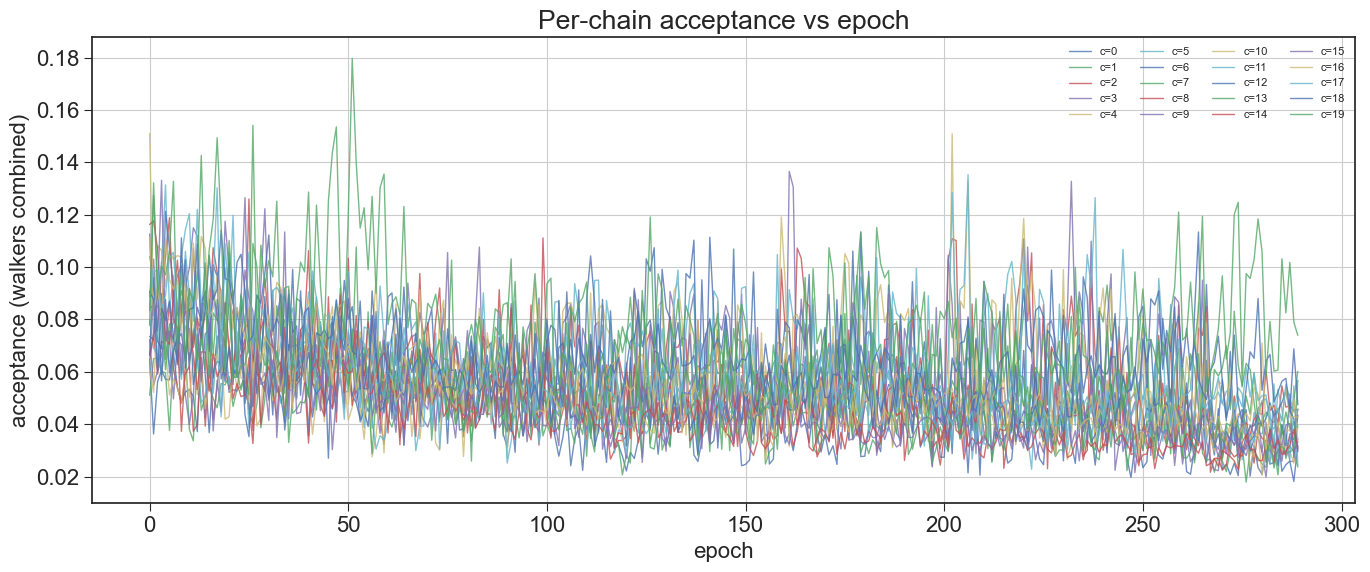

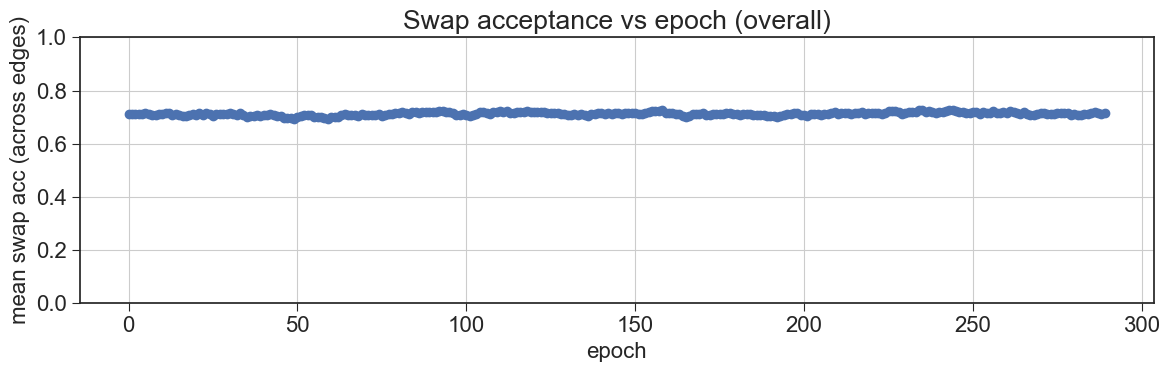

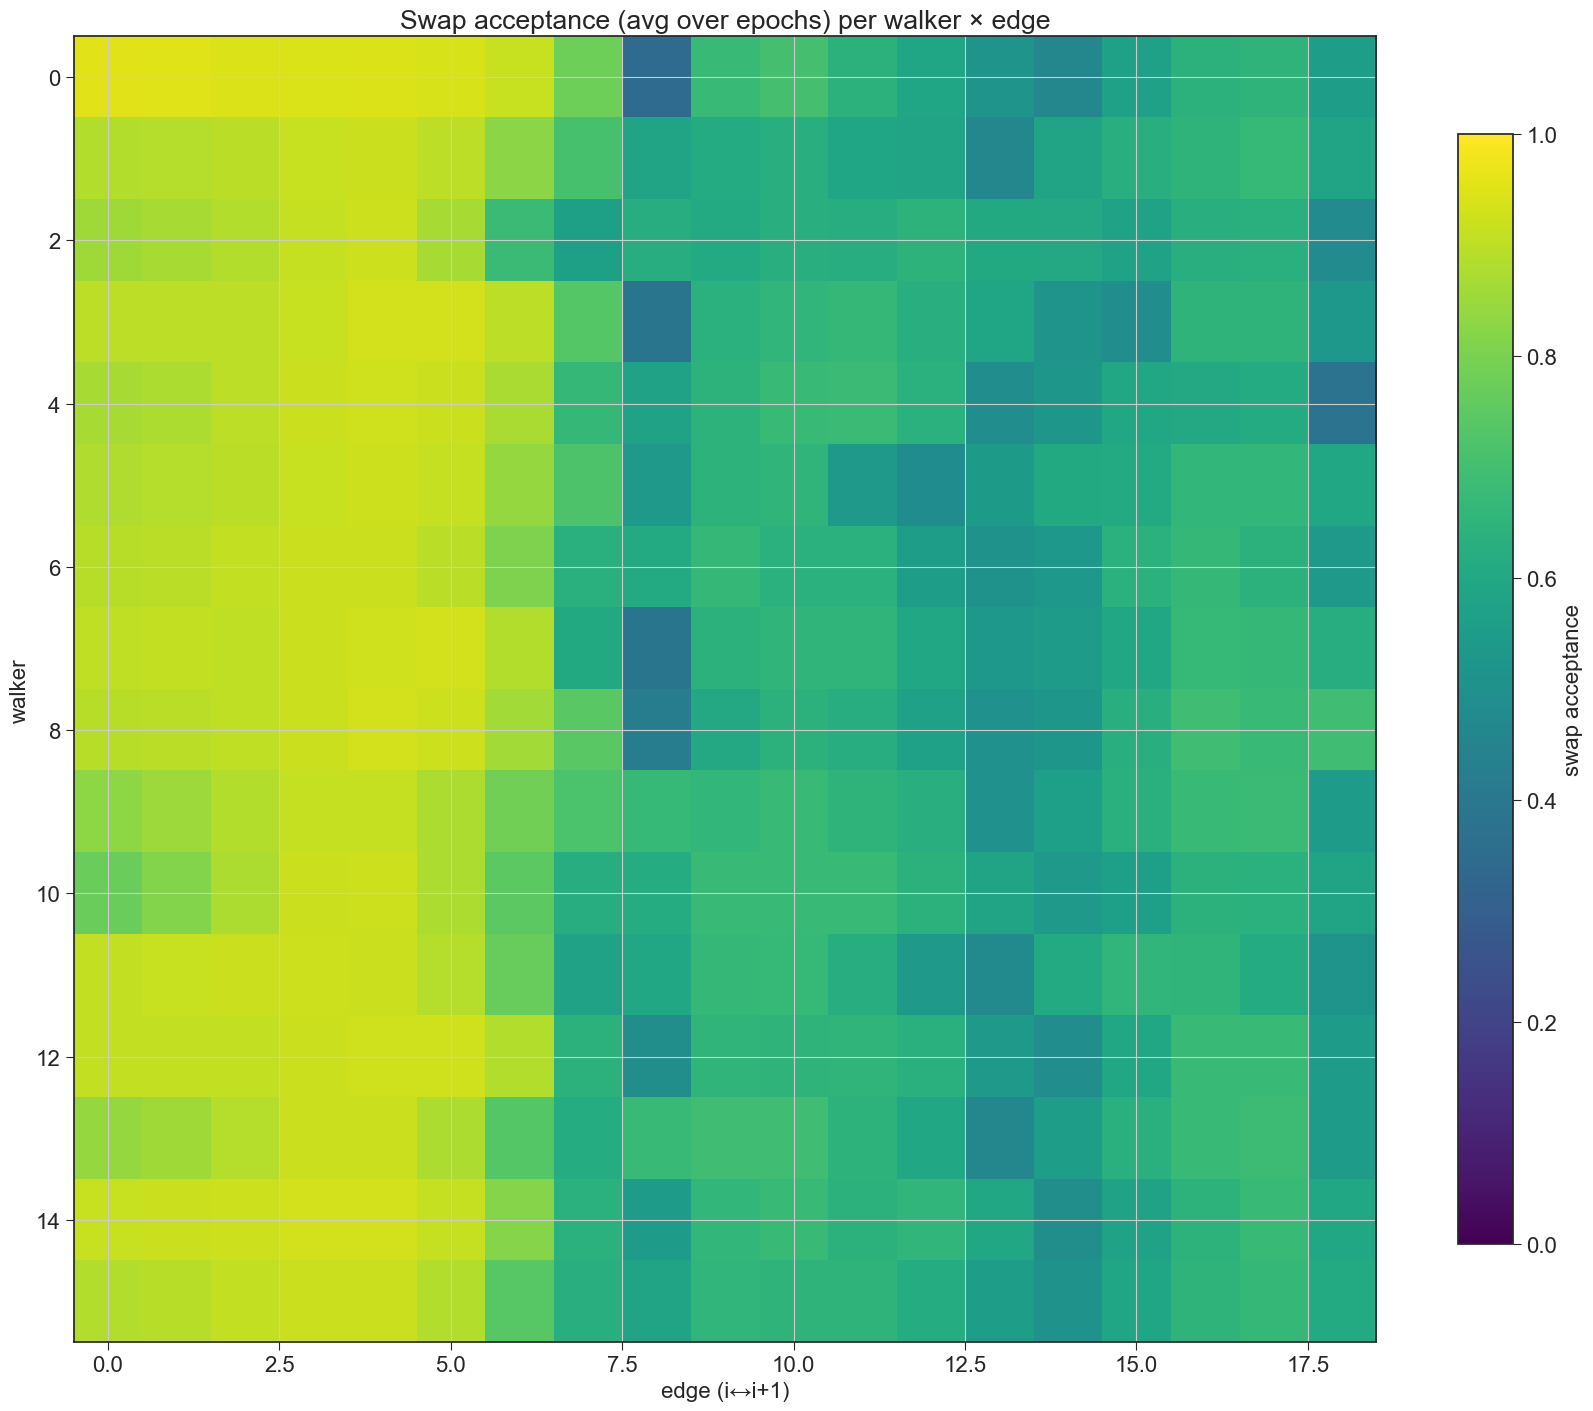

In [12]:
plot_acceptance_diagnostics(out_info, burnin_epochs=10)

In [13]:
def posterior_samples_by_model(out, c, *, burnin_epochs=0, model="M2"):
    """
    Returns:
      per_walker: list length W, each (N,D) accepted samples for that model
      pooled: (N,D) concatenated across walkers
    """
    per_walker = get_points_per_cw(out, c, burnin_epochs=burnin_epochs, model=model)
    pooled = pool_walkers(per_walker)
    return per_walker, pooled

def plot_posterior_scatter_by_model(out, c, dims=(0,1), *, burnin_epochs=0):
    per2, pool2 = posterior_samples_by_model(out, c, burnin_epochs=burnin_epochs, model="M2")
    per3, pool3 = posterior_samples_by_model(out, c, burnin_epochs=burnin_epochs, model="M3")

    d1, d2 = dims
    plt.figure(figsize=(7,6))
    if pool2.size:
        plt.scatter(pool2[:, d1], pool2[:, d2], s=6, alpha=0.4, label="M2")
    if pool3.size:
        plt.scatter(pool3[:, d1], pool3[:, d2], s=6, alpha=0.4, label="M3")
    if not pool2.size and not pool3.size:
        plt.text(0.5,0.5,"No accepted samples after burn-in", ha='center', va='center')
        plt.axis('off')
    else:
        plt.xlabel(f"θ[{d1}]"); plt.ylabel(f"θ[{d2}]")
        plt.title(f"Pooled accepted samples @ temp c={c} (M2 vs M3)")
        plt.legend()
    plt.tight_layout(); plt.show()


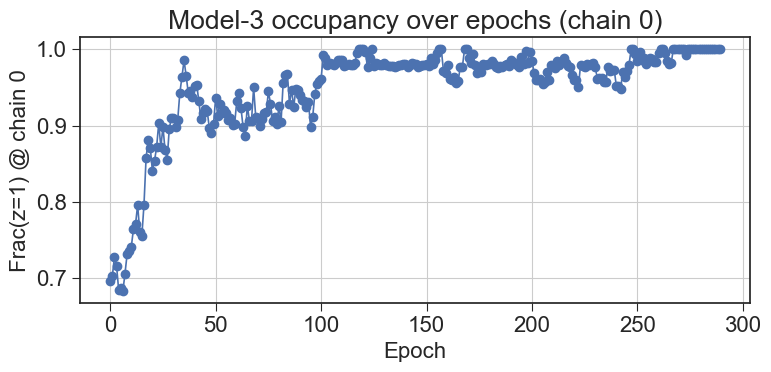

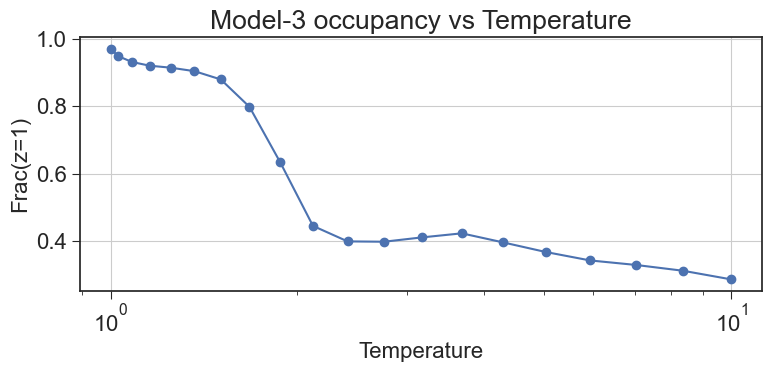

In [14]:
# def plot_M3_occupancy(out, *, burnin_epochs=0):
#     """
#     Uses z_time_in_M3 from SlimInfoPS (fraction of steps in M3 within the epoch).
#     Averages over epochs (post burn-in) and over walkers per temperature.
#     """
#     slims = out["slim_per_epoch"][burnin_epochs:]
#     if not slims:
#         print("No epochs after burn-in.")
#         return
#     Z = np.stack([np.asarray(s.z_time_in_M3) for s in slims], axis=0)  # (E', C, W)
#     occ = Z.mean(axis=(0,2))  # (C,) avg over epochs and walkers
#     C = occ.size

#     plt.figure(figsize=(10,4))
#     plt.plot(np.arange(C), occ, marker='o')
#     plt.ylim(0,1)
#     plt.xlabel("temperature index c")
#     plt.ylabel("P(z=1 | data, T_c) (avg)")
#     plt.title("M3 occupancy vs temperature (avg over epochs & walkers)")
#     plt.tight_layout(); plt.show()

#     return occ  # handy to reuse
# plot_posterior_scatter_by_model(out_info, c=0, burnin_epochs=10)

def plot_z_fraction_over_epochs_new(out, chain=0, *, burnin_epochs=0):
    """
    Plot fraction of steps in M3 at a given chain index across epochs,
    averaged over walkers.
    """
    slims = out["slim_per_epoch"][burnin_epochs:]
    if not slims:
        print("No epochs after burn-in.")
        return
    
    # (E, C, W) -> (E,)
    frac = np.array([s.z_time_in_M3[chain].mean() for s in slims])
    
    plt.figure(figsize=(8,4))
    plt.plot(frac, marker='o', lw=1.2)
    plt.xlabel("Epoch")
    plt.ylabel("Frac(z=1) @ chain {}".format(chain))
    plt.title(f"Model-3 occupancy over epochs (chain {chain})")
    plt.tight_layout()
    plt.show()


def plot_z_fraction_per_temperature_new(out, burnin_frac=0.2):
    """
    Plot occupancy fraction of M3 vs temperature, averaging over
    post-burnin epochs and walkers.
    """
    slims = out["slim_per_epoch"]
    E = len(slims)
    if E == 0:
        print("No epochs to plot.")
        return
    
    bE = int(np.floor(burnin_frac * E))
    slims = slims[bE:]
    
    if not slims:
        print("No epochs after burn-in.")
        return
    
    # stack across epochs: (E', C, W)
    Z = np.stack([s.z_time_in_M3 for s in slims], axis=0)
    frac_T = Z.mean(axis=(0,2))  # (C,)
    
    # temps = np.asarray(out["temperatures"])  # (C,)
    
    plt.figure(figsize=(8,4))
    plt.plot(temps, frac_T, 'o-', lw=1.5)
    plt.xlabel("Temperature")
    plt.ylabel("Frac(z=1)")
    plt.title("Model-3 occupancy vs Temperature")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()


plot_z_fraction_over_epochs_new(out_info, chain=0, burnin_epochs=10)
plot_z_fraction_per_temperature_new(out_info, burnin_frac=0.2)

In [15]:
def estimate_bayes_factor(out, *, burnin_epochs=0, c=0, log_prior_z=(0.0, 0.0)):
    slims = out["slim_per_epoch"][burnin_epochs:]
    if not slims:
        return np.nan
    Z = np.stack([np.asarray(s.z_time_in_M3) for s in slims], axis=0)  # (E', C, W)
    p_hat = Z[:, c, :].mean()   # average over epochs & walkers at cold chain
    p_hat = float(np.clip(p_hat, 1e-6, 1-1e-6))
    odds_post = p_hat / (1.0 - p_hat)
    odds_prior = np.exp(log_prior_z[1] - log_prior_z[0])
    BF_31 = odds_post / odds_prior
    return BF_31, p_hat, odds_post, odds_prior

def print_bayes_factor(out, *, burnin_epochs=0, c=0, log_prior_z=(0.0, 0.0)):
    BF_31, p_hat, odds_post, odds_prior = estimate_bayes_factor(
        out, burnin_epochs=burnin_epochs, c=c, log_prior_z=log_prior_z
    )
    print(f"[Bayes factor M3 vs M2] @ temp c={c}")
    print(f"  p_hat (M3 posterior prob) ≈ {p_hat:.4f}")
    print(f"  posterior odds ≈ {odds_post:.4f}")
    print(f"  prior  odds    =  exp(logπ3-logπ2) = {odds_prior:.4f}")
    print(f"  BF_32 = odds_post / odds_prior ≈ {BF_31:.4f}")


In [16]:
print_bayes_factor(out_info, burnin_epochs=100, c=0, log_prior_z=(0.0, 0.0))

[Bayes factor M3 vs M2] @ temp c=0
  p_hat (M3 posterior prob) ≈ 0.9793
  posterior odds ≈ 47.4027
  prior  odds    =  exp(logπ3-logπ2) = 1.0000
  BF_32 = odds_post / odds_prior ≈ 47.4027


In [17]:


def _pool_model_across_epochs_walkers(
    slims, c, *, which: str, burnin_frac=0.5, thin=1
):
    """
    Pool accepted points & log-probs for a specific model across
    the provided SlimInfoPS list (epochs) and all walkers at temperature c.

    which: "M2" or "M3"
    Returns: (points: (N,D) array, logprobs: (N,) array)
    """
    pts_key = f"accepted_points_{which}"
    lp_key  = f"accepted_logprob_{which}"

    pooled_pts = []
    pooled_lp  = []

    for s in slims:
        pts_c_list = getattr(s, pts_key)[c]  # list length W: arrays (N_acc_w,D)
        lp_c_list  = getattr(s, lp_key)[c]   # list length W: arrays (N_acc_w,)

        for arr_pts, arr_lp in zip(pts_c_list, lp_c_list):
            if arr_pts is None or arr_pts.size == 0:
                continue
            n = len(arr_pts)
            b0 = int(n * burnin_frac)
            keep_pts = arr_pts[b0::thin]
            keep_lp  = arr_lp[b0::thin]
            if keep_pts.size:
                pooled_pts.append(keep_pts)
                pooled_lp.append(keep_lp)

    if not pooled_pts:
        return np.empty((0, 0)), np.empty((0,))
    return np.vstack(pooled_pts), np.concatenate(pooled_lp)


def accepted_by_model_combined(
    out, c: int, *, burnin_epochs=0, burnin_frac=0.5, thin=1
):
    """
    Return combined accepted points & log-probs for M2 and M3 at temperature index c.
    Pools over all walkers and all epochs after `burnin_epochs`.
    Burn-in/thinning are applied within each (epoch, walker) sequence.

    Returns:
      (pts_M2, lp_M2), (pts_M3, lp_M3)
      where pts_* shape is (N,D), lp_* shape is (N,)
    """
    slims = out["slim_per_epoch"][burnin_epochs:]
    if not slims:
        return (np.empty((0,0)), np.empty((0,))), (np.empty((0,0)), np.empty((0,)))

    pts2, lp2 = _pool_model_across_epochs_walkers(
        slims, c, which="M2", burnin_frac=burnin_frac, thin=thin
    )
    pts3, lp3 = _pool_model_across_epochs_walkers(
        slims, c, which="M3", burnin_frac=burnin_frac, thin=thin
    )
    return (pts2, lp2), (pts3, lp3)


def accepted_by_model_per_walker(
    out, c: int, *, burnin_epochs=0, burnin_frac=0.5, thin=1, which="M2"
):
    """
    Pool across epochs, but keep a list per walker for a given model.
    Returns:
      points_list: [ np.ndarray (N_w, D) for each walker w ]
      logprobs_list: [ np.ndarray (N_w,) for each walker w ]
    """
    slims = out["slim_per_epoch"][burnin_epochs:]
    if not slims:
        return [], []

    # infer W from the last epoch
    W = len(getattr(slims[-1], f"accepted_points_{which}")[c])

    pts_per_w = [[] for _ in range(W)]
    lp_per_w  = [[] for _ in range(W)]

    for s in slims:
        pts_c_list = getattr(s, f"accepted_points_{which}")[c]
        lp_c_list  = getattr(s, f"accepted_logprob_{which}")[c]
        for w, (arr_pts, arr_lp) in enumerate(zip(pts_c_list, lp_c_list)):
            if arr_pts is None or arr_pts.size == 0:
                continue
            n = len(arr_pts)
            b0 = int(n * burnin_frac)
            keep_pts = arr_pts[b0::thin]
            keep_lp  = arr_lp[b0::thin]
            if keep_pts.size:
                pts_per_w[w].append(keep_pts)
                lp_per_w[w].append(keep_lp)

    pts_out = [np.vstack(p) if p else np.empty((0,0)) for p in pts_per_w]
    lp_out  = [np.concatenate(p) if p else np.empty((0,)) for p in lp_per_w]
    return pts_out, lp_out


M2 combined: (7538, 24) (7538,)
M3 combined: (21666, 24) (21666,)
M2 per-walker: 16 (0, 0) 16
M3 per-walker: 16 (1345, 24) 16


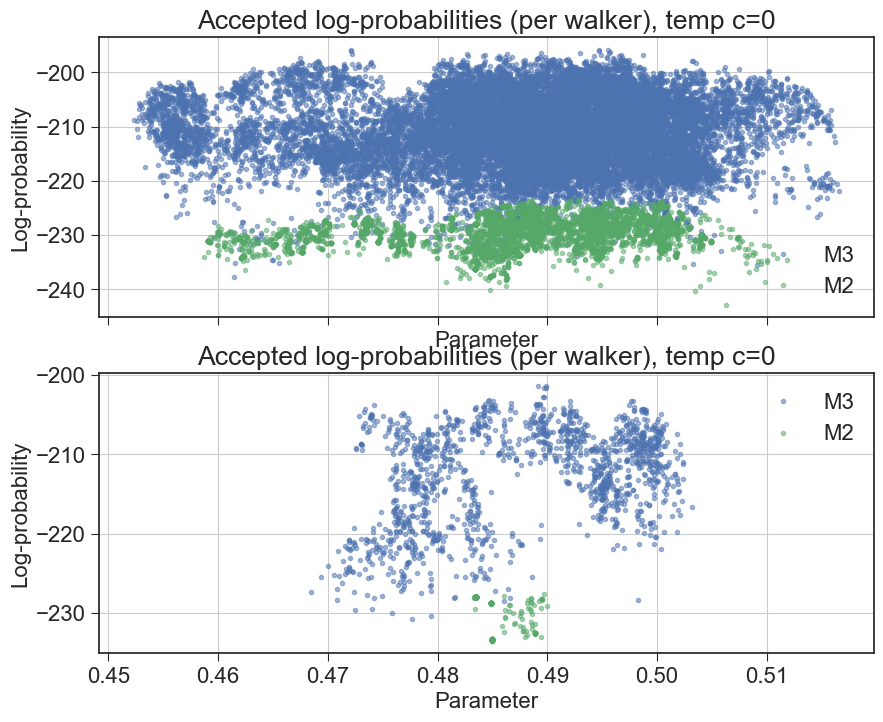

In [35]:
c = 0
burnin_epochs = 100
burnin_frac = 0.1
thin = 2

# Combined over walkers (and epochs after burn-in)
(M2_pts, M2_lp), (M3_pts, M3_lp) = accepted_by_model_combined(
    out_info, c, burnin_epochs=burnin_epochs, burnin_frac=burnin_frac, thin=thin
)

print("M2 combined:", M2_pts.shape, M2_lp.shape)
print("M3 combined:", M3_pts.shape, M3_lp.shape)

# Per-walker (still pooled across epochs)
M2_pts_w, M2_lp_w = accepted_by_model_per_walker(
    out_info, c, burnin_epochs=burnin_epochs, burnin_frac=burnin_frac, thin=thin, which="M2"
)
M3_pts_w, M3_lp_w = accepted_by_model_per_walker(
    out_info, c, burnin_epochs=burnin_epochs, burnin_frac=burnin_frac, thin=thin, which="M3"
)
print("M2 per-walker:", len(M2_pts_w), np.shape(M2_pts_w[0]), len(M2_lp_w))
print("M3 per-walker:", len(M3_pts_w), np.shape(M3_pts_w[0]), len(M3_lp_w))

# Example: quick log-prob hist for M3 combined
# import matplotlib.pyplot as plt
# if M3_lp.size:
#     plt.figure(figsize=(7,4))
#     plt.hist(M3_lp, bins=40, density=True, alpha=0.7)
#     plt.xlabel("log p(θ | M3)")
#     plt.ylabel("density")
#     plt.title(f"M3 accepted log-prob (combined), temp c={c}")
#     plt.tight_layout()
#     plt.show()

# wlkr = 3, 4, 6, 9, 11
wlkr = 15

fg100, ax = plt.subplots(2, sharex=True, figsize=(10, 8))
ax[0].plot(M3_pts[:, 1], M3_lp, '.', alpha=0.5, label='M3')
ax[0].plot(M2_pts[:, 1], M2_lp, '.', alpha=0.5, label='M2')

ax[0].set_xlabel("Parameter")
ax[0].set_ylabel("Log-probability")
ax[0].set_title(f"Accepted log-probabilities (per walker), temp c={c}")
ax[0].legend()
# ax[0].tight_layout()
# ax[0].show()


ax[1].plot(M3_pts_w[wlkr][:, 1], M3_lp_w[wlkr], '.', alpha=0.5, label='M3')
ax[1].plot(M2_pts_w[wlkr][:, 1], M2_lp_w[wlkr], '.', alpha=0.5, label='M2')
ax[1].set_xlabel("Parameter")
ax[1].set_ylabel("Log-probability")
ax[1].set_title(f"Accepted log-probabilities (per walker), temp c={c}")
ax[1].legend()
# ax[1].tight_layout()

plt.show()


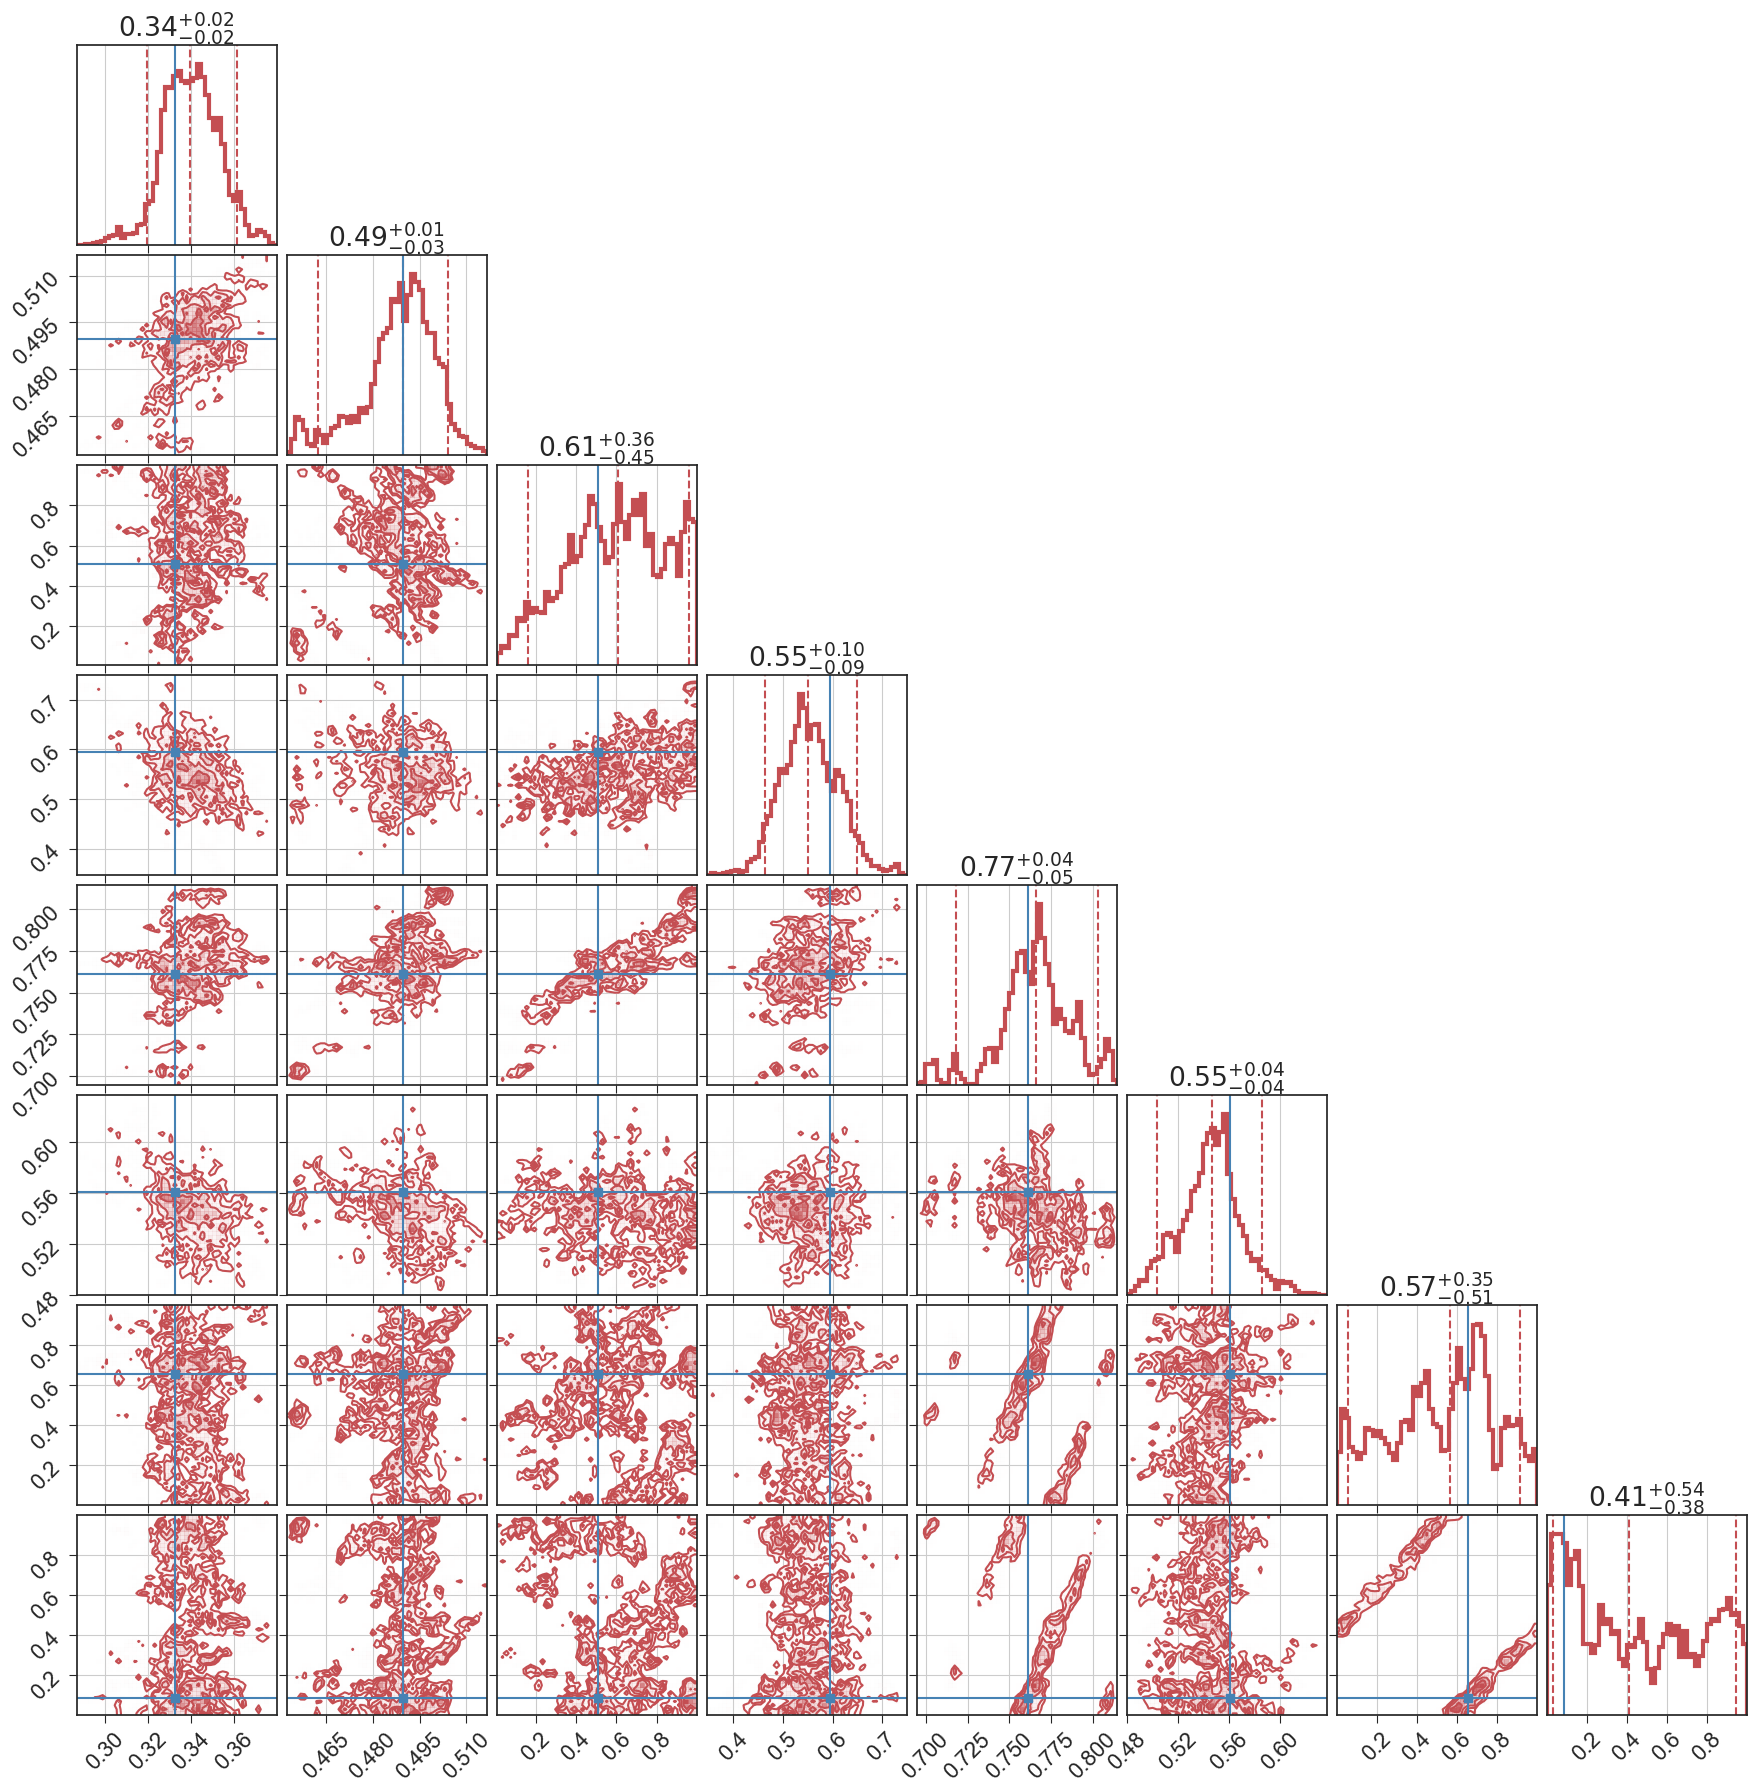

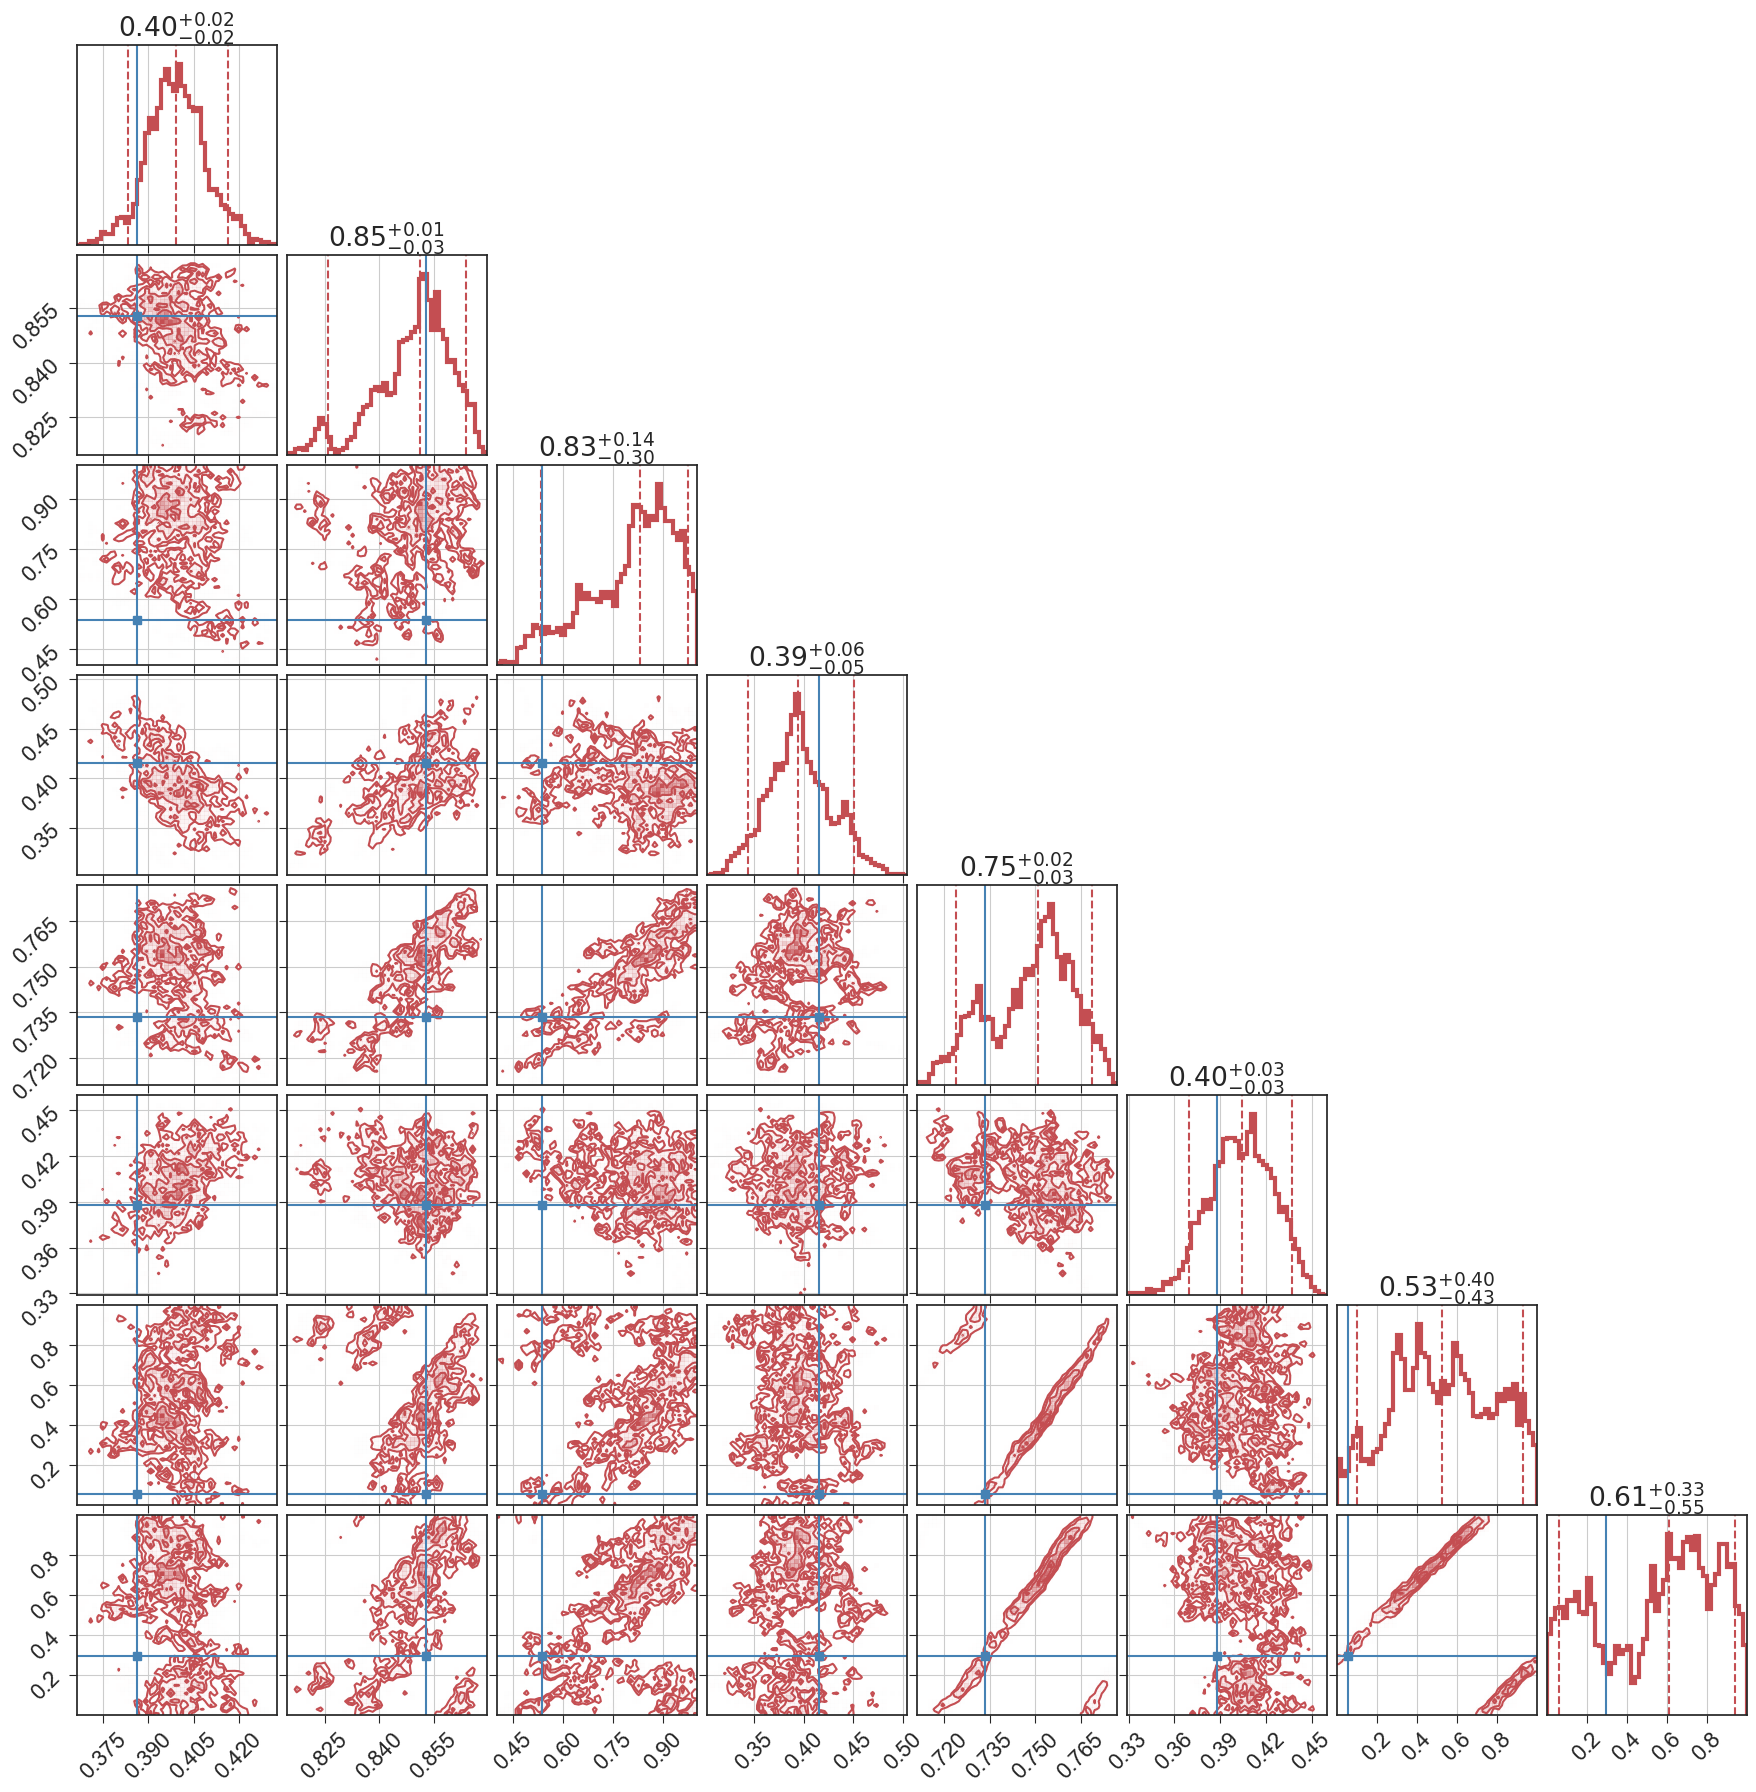

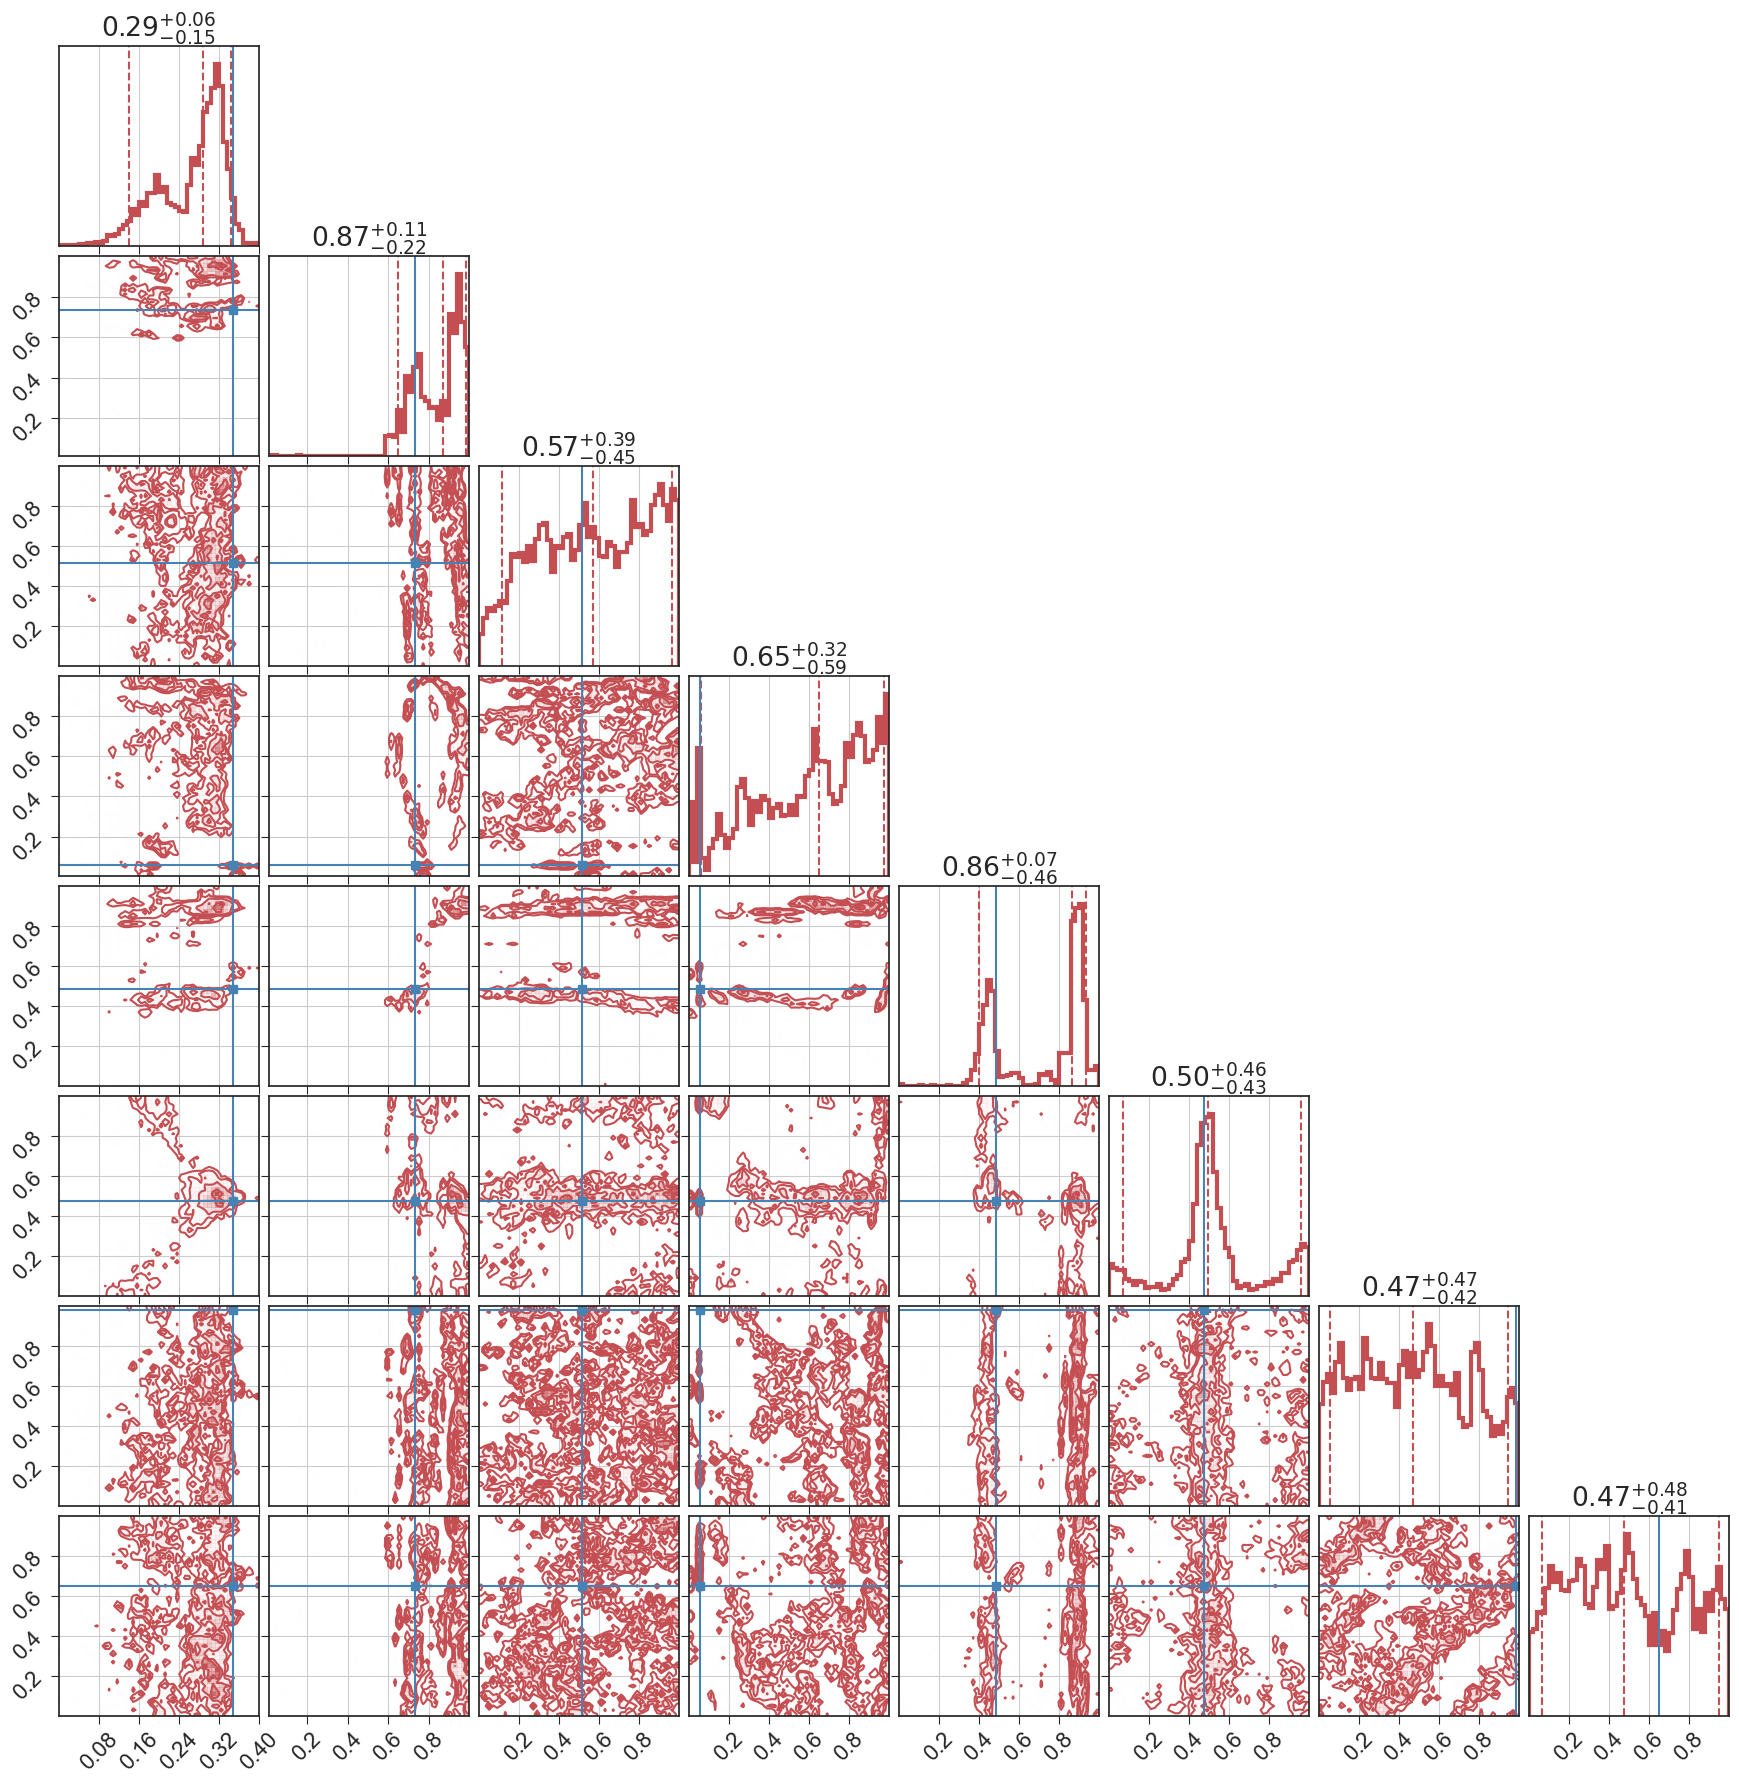

In [36]:
import matplotlib.lines as mlines

start = 0
fig300 = corner.corner(M3_pts[start:, :8], bins=50, hist_kwargs={'density':True, 'lw':3}, 
                    plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
                    show_titles=True, color='C2', use_math_test=True, truths=_srcHC245[:8]) 

# corner.corner(ery_samples[:, :8], fig=fig300,bins=50, hist_kwargs={'density':True, 'lw':3},
#               plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
#               show_titles=True, color='C1', use_math_test=True, truths=_srcHC245[:8])

# line1 = mlines.Line2D([], [], color='C1', label='eryn')
# line2 = mlines.Line2D([], [], color='C2', label='my')

# Add the legend to the figure
# fig300.legend(handles=[line1, line2], loc='upper right', fontsize=20)

fig310 = corner.corner(M3_pts[start:, 8:16], bins=50, hist_kwargs={'density':True, 'lw':3}, 
                    plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
                    show_titles=True, color='C2', use_math_test=True, truths=_srcHC245[8:16]  ) 


# corner.corner(ery_samples[:, 8:16], fig=fig310, bins=50, hist_kwargs={'density':True, 'lw':3},
#               plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
#               show_titles=True, color='C1', use_math_test=True, truths=_srcHC245[8:16])

fig320 = corner.corner(M3_pts[start:, 16:24], bins=50, hist_kwargs={'density':True, 'lw':3}, 
                    plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
                    show_titles=True, color='C2', use_math_test=True, truths=_srcHC245[16:24]) 

# corner.corner(ery_samples[:, 16:24], fig=fig320, bins=50, hist_kwargs={'density':True, 'lw':3},
#               plot_datapoints=False, fill_contours=False, quantiles=[0.05, 0.5, 0.95],
#               show_titles=True, color='C1', use_math_test=True, truths=_srcHC245[16:24])

 
plt.show()